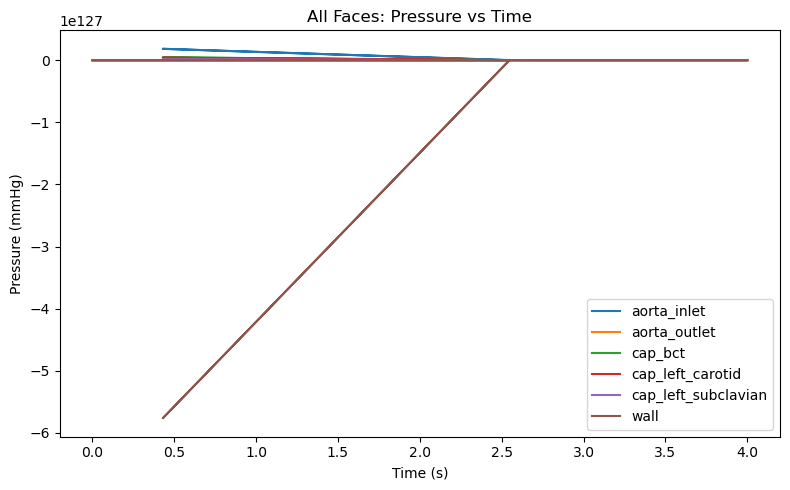

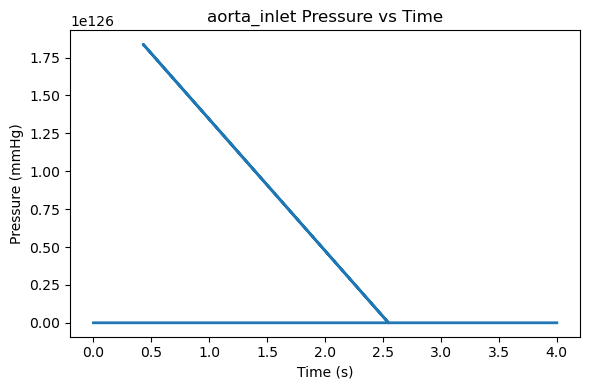

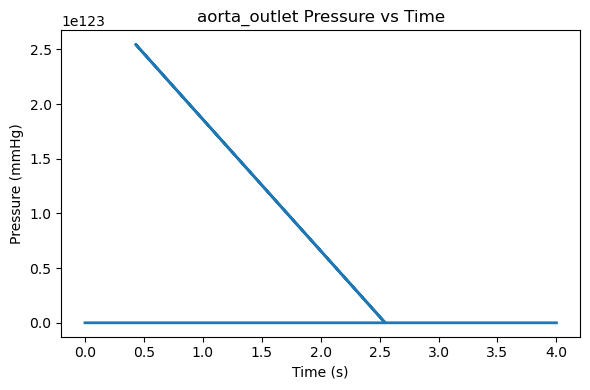

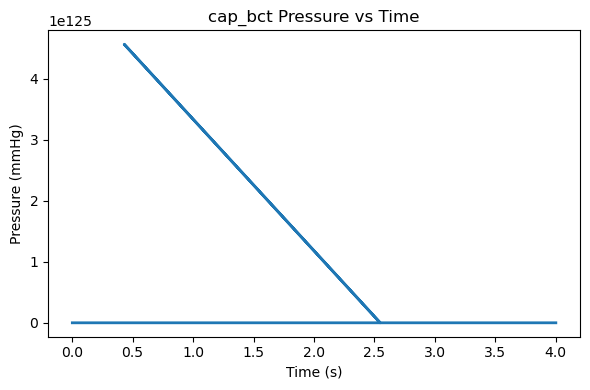

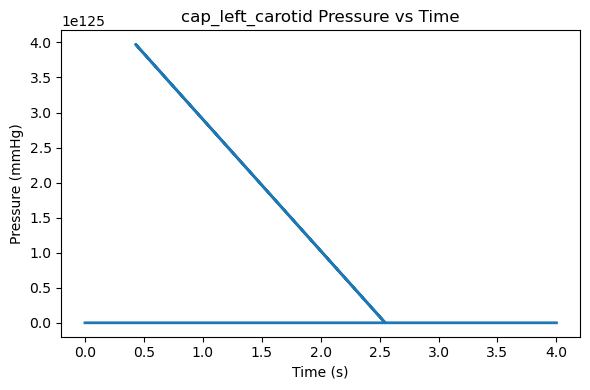

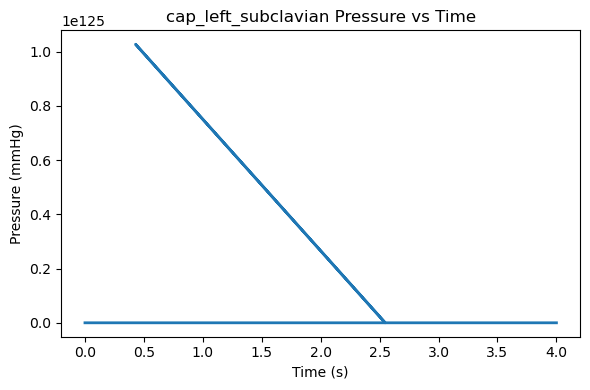

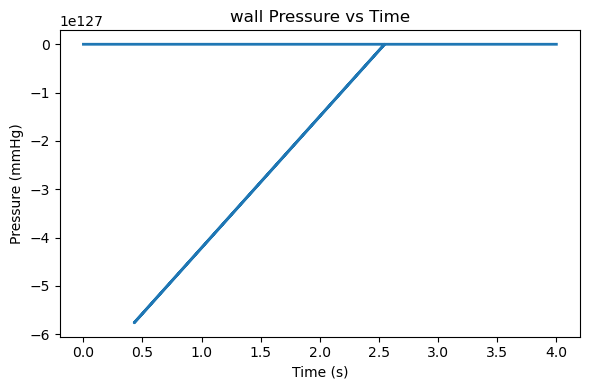

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) name of your data file
filename = "B_CM_Pressure_average.txt"

# 2) find the header line (starts with "step")
with open(filename, 'r') as f:
    for idx, line in enumerate(f):
        if line.lstrip().startswith("step"):
            header_idx = idx
            columns = line.strip().split()
            break

# 3) read the data block into a DataFrame
df = pd.read_csv(
    filename,
    sep=r'\s+',
    comment='#',
    header=None,
    names=columns,
    skiprows=header_idx+1
)

# 4) drop the 'step' column (we only need time + the faces)
df = df.drop(columns=['step'])

# list of all face‐columns (everything except 'time')
faces = [c for c in df.columns if c != 'time']

# 5) combined chart
plt.figure(figsize=(8,5))
for face in faces:
    plt.plot(df['time'], df[face]/1333.22, label=face)
plt.xlabel('Time (s)')
plt.ylabel('Pressure (mmHg)')
plt.title('All Faces: Pressure vs Time')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 6) one chart per face
for face in faces:
    plt.figure(figsize=(6,4))
    plt.plot(df['time'], df[face]/1333.22, linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (mmHg)')
    plt.title(f'{face} Pressure vs Time')
    plt.tight_layout()
    plt.show()



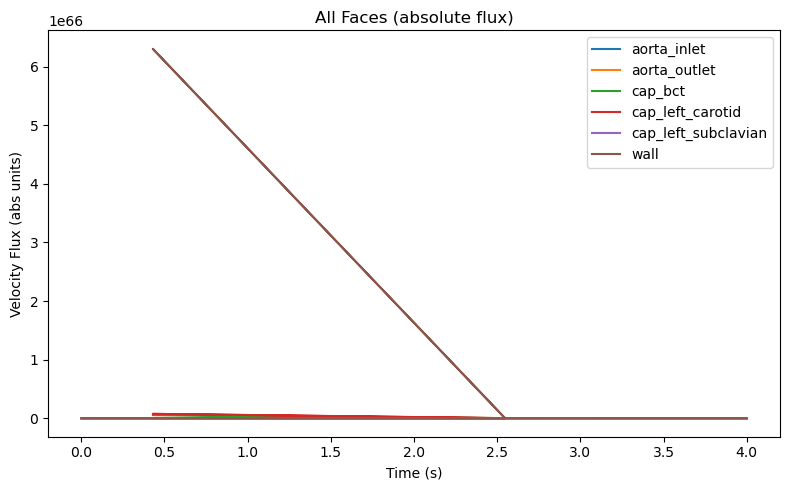

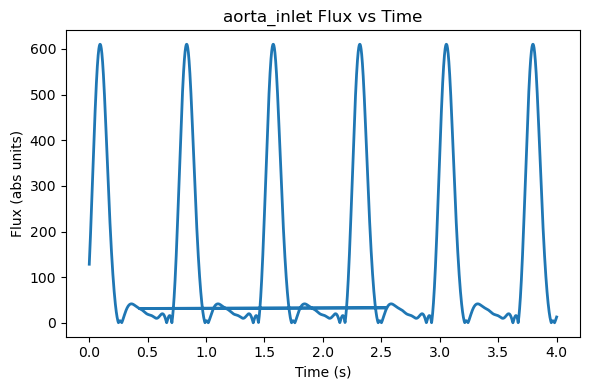

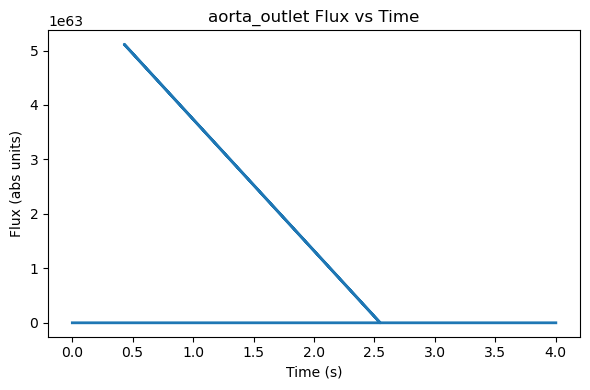

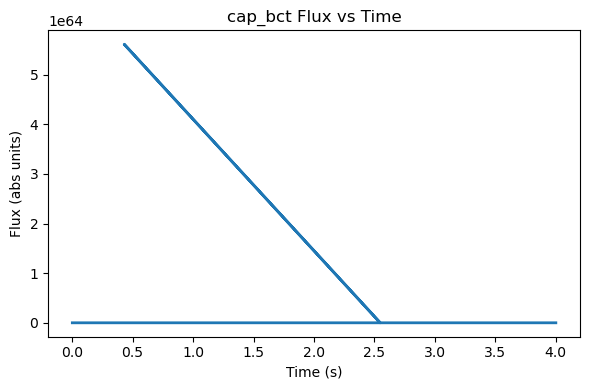

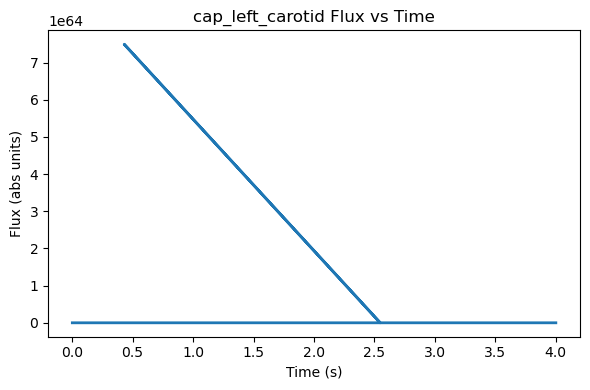

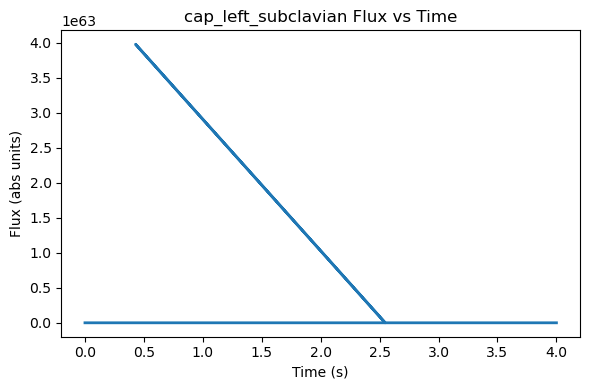

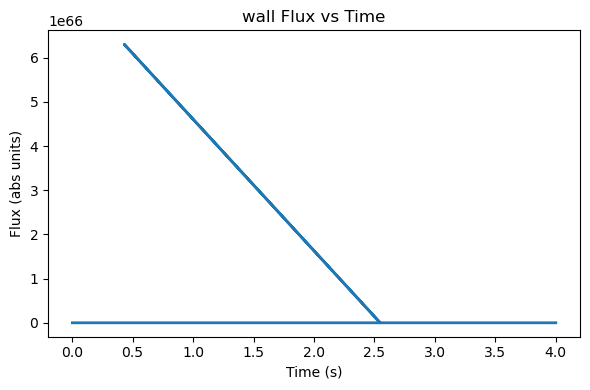

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

filename = "B_CM_Velocity_flux.txt"

# 1) find header
with open(filename, 'r') as f:
    for idx, line in enumerate(f):
        if line.lstrip().startswith("step"):
            header_idx = idx
            columns = line.strip().split()
            break

# 2) read into DataFrame
df = pd.read_csv(
    filename,
    sep=r'\s+',
    comment='#',
    header=None,
    names=columns,
    skiprows=header_idx+1
)

# 3) drop 'step' and take absolute value of every data column
df = df.drop(columns=['step'])
data_cols = [c for c in df.columns if c != 'time']
df[data_cols] = df[data_cols].abs()

# 4) single combined chart (optional)
plt.figure(figsize=(8,5))
for face in data_cols:
    plt.plot(df['time'], df[face], label=face)
plt.xlabel('Time (s)')
plt.ylabel('Velocity Flux (abs units)')
plt.title('All Faces (absolute flux)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 5) one chart per face
for face in data_cols:
    plt.figure(figsize=(6,4))
    plt.plot(df['time'], df[face], linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Flux (abs units)')
    plt.title(f'{face} Flux vs Time')
    plt.tight_layout()
    plt.show()

Coarctation file exists? → True
Inflate file exists? → True
Coarctation ['time', 'aorta_inlet', 'aorta_outlet', 'cap_bct', 'cap_left_carotid', 'cap_left_subclavian', 'wall']
Inflate ['time', 'aorta_inlet', 'aorta_outlet', 'cap_bct', 'cap_left_carotid', 'cap_left_subclavian', 'wall']
Coarctation: kept 4000/4001 rows after outlier removal
Inflate: kept 4000/4000 rows after outlier removal


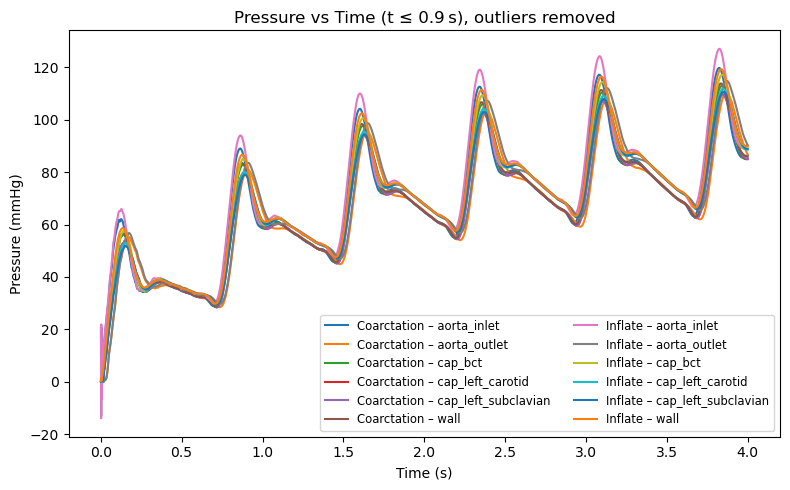

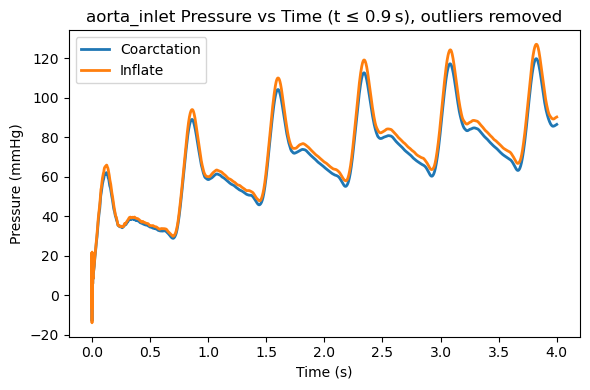

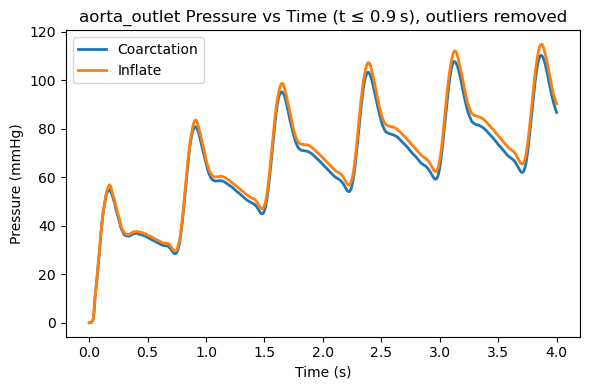

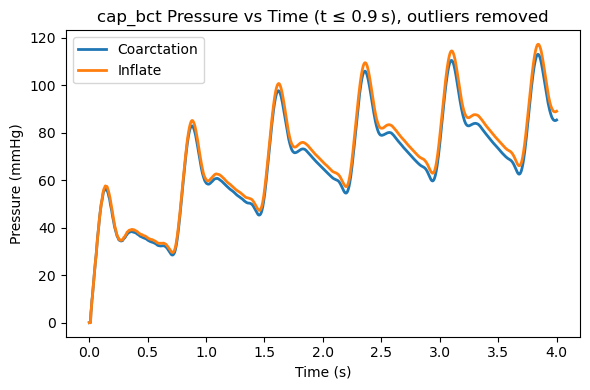

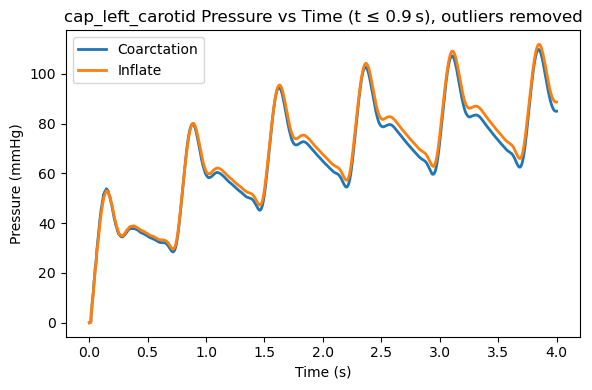

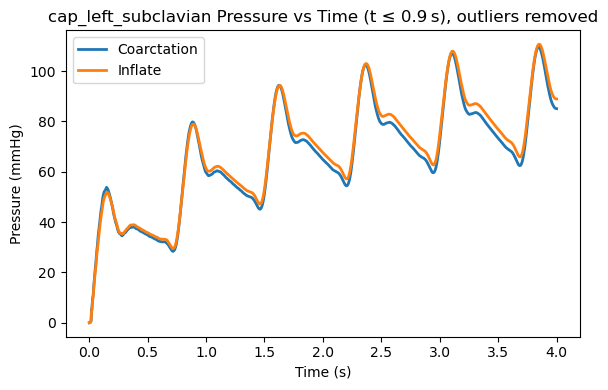

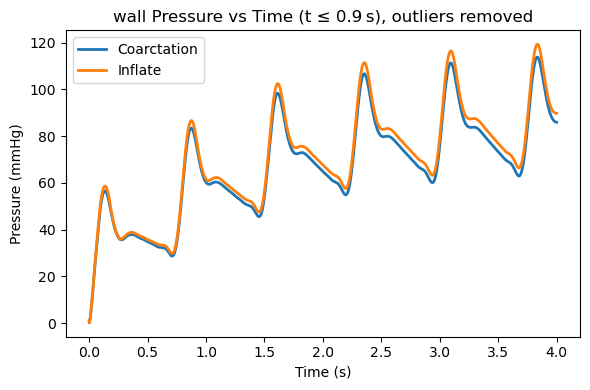

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def read_pressure_file(filepath):
    """
    Read a B_CM_Pressure_average.txt into a DataFrame:
      - finds the "step" header row,
      - loads columns = ['step', 'time', face1, face2, …],
      - drops 'step'.
    """
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                columns = line.strip().split()
                break

    df = pd.read_csv(
        filepath,
        sep=r'\s+',
        comment='#',
        header=None,
        names=columns,
        skiprows=header_idx+1
    )
    return df.drop(columns=['step'])


def remove_outliers_iqr(df, face_cols, k=1.5):
    """
    Drop any row where *any* face column exceeds Q3 + k·IQR.
    """
    mask = pd.Series(True, index=df.index)
    for face in face_cols:
        q1 = df[face].quantile(0.25)
        q3 = df[face].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + k * iqr
        mask &= df[face] <= upper
    return df[mask]


# ----------------------------------------------------------------------
# 1) Build paths
cwd = os.getcwd()
coarc_pres_path = os.path.join(cwd, "B_CM_Pressure_average.txt")
base = os.path.abspath(os.path.join(cwd, os.pardir, os.pardir))
inflate_pres_path = os.path.join(
    base, "svFSI", "svFSI_Inflate", "aorta_cmm", "48-procs",
    "B_CM_Pressure_average.txt"
)

# 1.5) map case names to paths
cases = {
    "Coarctation": coarc_pres_path,
    "Inflate"    : inflate_pres_path,
}

# 2) sanity‐check
for name, p in [("Coarctation", coarc_pres_path), ("Inflate", inflate_pres_path)]:
    print(f"{name} file exists? → {os.path.exists(p)}")

# 3) Read & time‐trim both cases
raw_dfs = {}
for case, path in cases.items():
    df = read_pressure_file(path)
    print(case, df.columns.tolist())
    # keep only t ≤ 0.9 s
    raw_dfs[case] = df[df['time'] <= 4].copy()

# 4) Restrict Inflate to only the times Coarctation has
coarc_times = raw_dfs['Coarctation']['time']
raw_dfs['Inflate'] = raw_dfs['Inflate'][raw_dfs['Inflate']['time'].isin(coarc_times)].copy()

# 5) Identify faces (once, from Coarctation)
faces = [c for c in raw_dfs['Coarctation'].columns if c != 'time']

# 6) Remove outliers (IQR‐rule) and build final dfs
dfs = {}
for case, df in raw_dfs.items():
    df_clean = remove_outliers_iqr(df, faces, k=1.5)
    print(f"{case}: kept {len(df_clean)}/{len(df)} rows after outlier removal")
    dfs[case] = df_clean

# ----------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt

# … (your read_pressure_file, remove_outliers_iqr, and data-prep code here) …

# make sure output folder exists
outdir = "figures"
os.makedirs(outdir, exist_ok=True)

# 4) Combined‐plot: all faces, both cases, but Inflate only at Coarctation times
plt.figure(figsize=(8,5))
coarc_times = dfs["Coarctation"]["time"]

for case, df in dfs.items():
    if case == "Inflate":
        df = df[df["time"].isin(coarc_times)]
    for face in faces:
        plt.plot(df['time'], df[face]/1333.22, label=f"{case} – {face}")

plt.xlabel('Time (s)')
plt.ylabel('Pressure (mmHg)')
plt.title('Pressure vs Time (t ≤ 0.9 s), outliers removed')
plt.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
# save combined figure
plt.savefig(os.path.join(outdir, "combined_pressure.png"), dpi=300)
plt.show()


# 5) Per‐face comparison, same restriction
for face in faces:
    plt.figure(figsize=(6,4))
    for case, df in dfs.items():
        plot_df = df
        if case == "Inflate":
            plot_df = df[df["time"].isin(coarc_times)]
        plt.plot(plot_df['time'], plot_df[face]/1333.22, linewidth=2, label=case)

    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (mmHg)')
    plt.title(f'{face} Pressure vs Time (t ≤ 0.9 s), outliers removed')
    plt.legend(loc='best')
    plt.tight_layout()
    # save each face figure
    filename = f"{face.replace('/', '_').replace(' ', '_')}_pressure.png"
    plt.savefig(os.path.join(outdir, filename), dpi=300)
    plt.show()


Coarctation: exists? True
Inflate: exists? True
Coarctation: dropped 769 / 4001 rows as outliers
Inflate: dropped 733 / 4000 rows as outliers


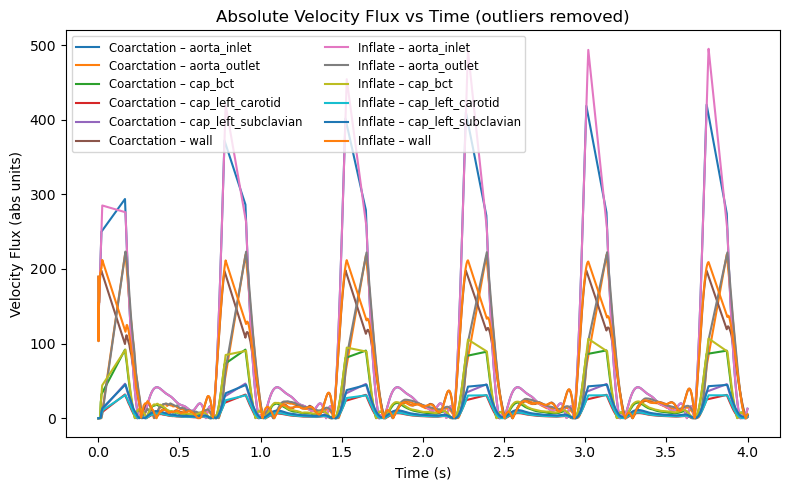

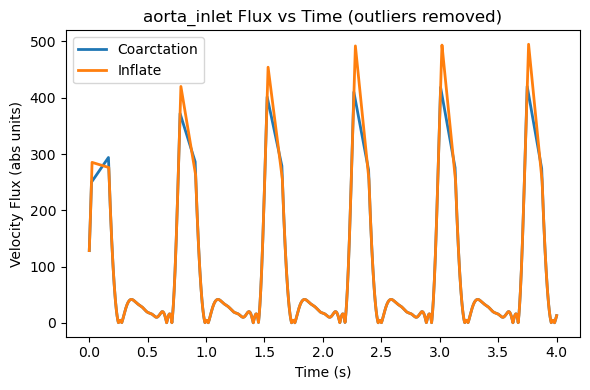

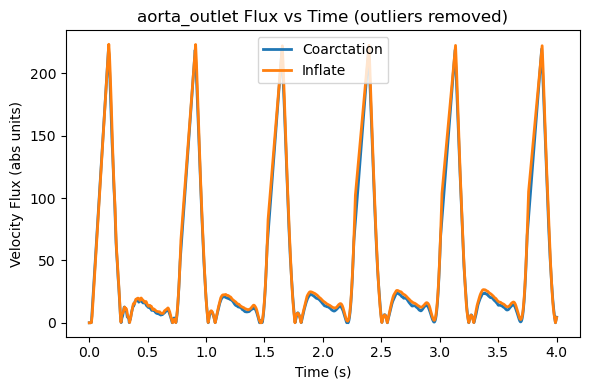

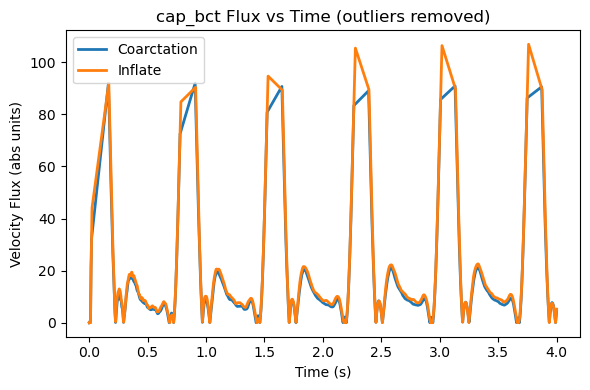

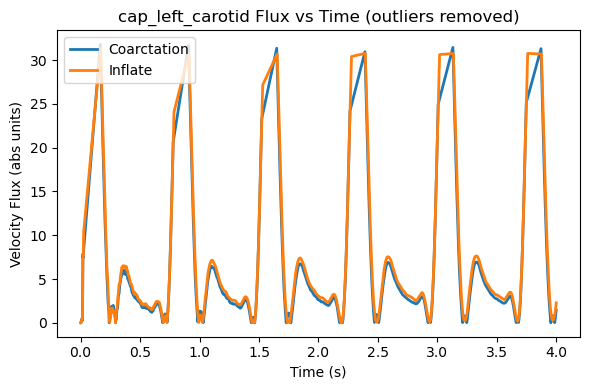

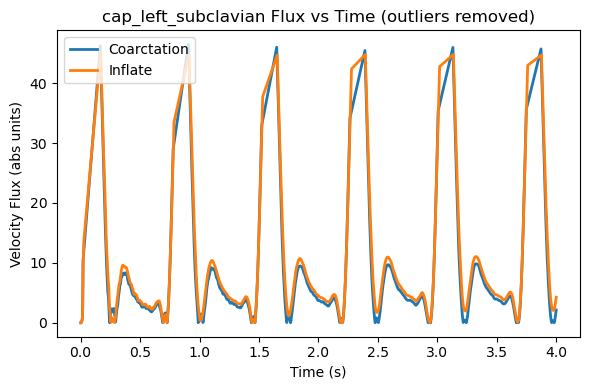

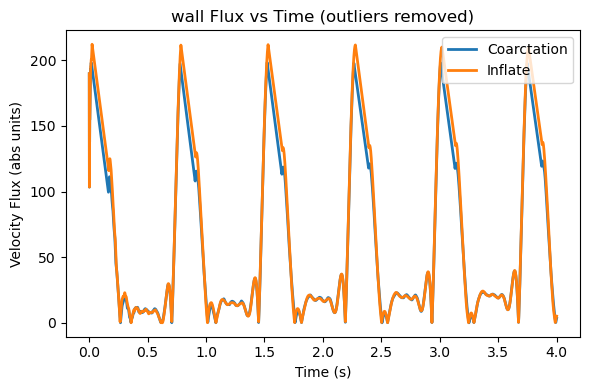

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def read_velocity_file(filepath):
    # … your existing reader …
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                columns = line.strip().split()
                break
    df = pd.read_csv(
        filepath,
        sep=r'\s+',
        comment='#',
        header=None,
        names=columns,
        skiprows=header_idx+1
    )
    df = df.drop(columns=['step'])
    data_cols = [c for c in df.columns if c != 'time']
    df[data_cols] = df[data_cols].abs()
    return df

def remove_outliers_iqr(df, cols, k=1.5):
    """
    Drop any row where any of the given cols exceeds Q3 + k·IQR.
    """
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + k * iqr
        mask &= df[c] <= upper
    return df[mask]

# ----------------------------------------------------------------------
cwd = os.getcwd()
coarc_vel_path = os.path.join(cwd, "B_CM_Velocity_flux.txt")
base = os.path.abspath(os.path.join(cwd, os.pardir, os.pardir))
inflate_vel_path = os.path.join(
    base, "svFSI", "svFSI_Inflate", "aorta_cmm", "48-procs",
    "B_CM_Velocity_flux.txt"
)

# sanity check
for name, p in [("Coarctation", coarc_vel_path), ("Inflate", inflate_vel_path)]:
    print(f"{name}: exists? {os.path.exists(p)}")

# 1) Read both—no trimming by time here
dfs_vel = {
    "Coarctation": read_velocity_file(coarc_vel_path),
    "Inflate"    : read_velocity_file(inflate_vel_path),
}

# 2) Restrict Inflate to only times present in Coarctation
coarc_times = dfs_vel["Coarctation"]["time"]
dfs_vel["Inflate"] = dfs_vel["Inflate"][dfs_vel["Inflate"]["time"].isin(coarc_times)].copy()

# 3) Identify face columns
faces = [c for c in dfs_vel['Coarctation'].columns if c != 'time']

# 4) Remove outliers from each case
for case, df in dfs_vel.items():
    before = len(df)
    df_clean = remove_outliers_iqr(df, faces, k=1.5)
    after = len(df_clean)
    print(f"{case}: dropped {before-after} / {before} rows as outliers")
    dfs_vel[case] = df_clean

import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# ensure output folder exists
outdir_vel = "figures_vel"
os.makedirs(outdir_vel, exist_ok=True)

# 4) Combined‐plot: all faces, both cases (line plots)
plt.figure(figsize=(8,5))
for case, df in dfs_vel.items():
    for face in faces:
        plt.plot(
            df['time'],
            df[face],
            linewidth=1.5,
            label=f"{case} – {face}"
        )
plt.xlabel('Time (s)')
plt.ylabel('Velocity Flux (abs units)')
plt.title('Absolute Velocity Flux vs Time (outliers removed)')
plt.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
# save combined velocity plot
plt.savefig(os.path.join(outdir_vel, "combined_velocity_flux.png"), dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 5) Per‐face comparison (line plots)
for face in faces:
    plt.figure(figsize=(6,4))
    for case, df in dfs_vel.items():
        plt.plot(
            df['time'],
            df[face],
            linewidth=2,
            label=case
        )
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity Flux (abs units)')
    plt.title(f'{face} Flux vs Time (outliers removed)')
    plt.legend(loc='best')
    plt.tight_layout()
    # sanitize face name for filename
    safe_face = face.replace('/', '_').replace(' ', '_')
    plt.savefig(os.path.join(outdir_vel, f"{safe_face}_velocity_flux.png"), dpi=300)
    plt.show()


Inflate pressure → exists? True
Inflate flux → exists? True
Coarctation pressure → exists? True
Coarctation flux → exists? True
Inflate pressure: dropped 208 / 7400 rows
Coarctation pressure: dropped 1 / 4001 rows
Inflate flux: dropped 1649 / 7400 rows
Coarctation flux: dropped 769 / 4001 rows


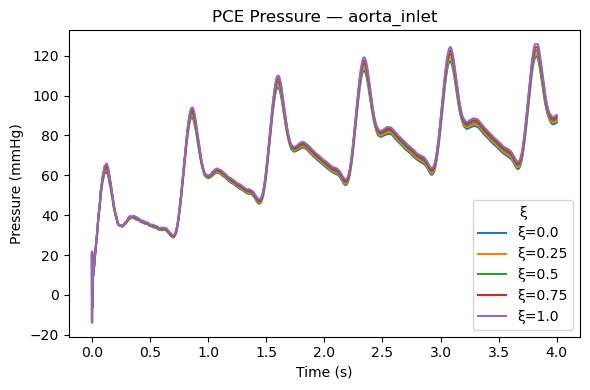

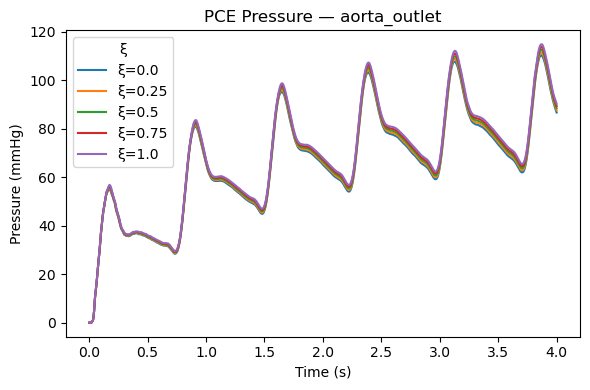

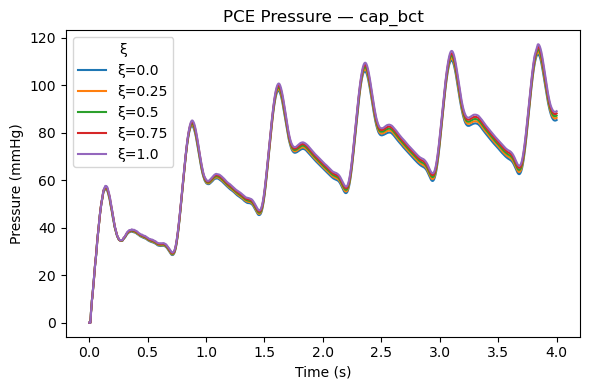

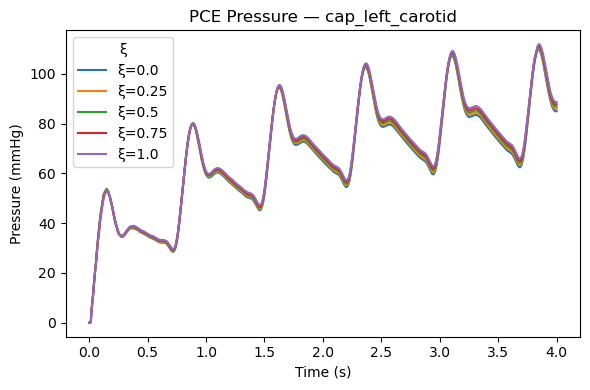

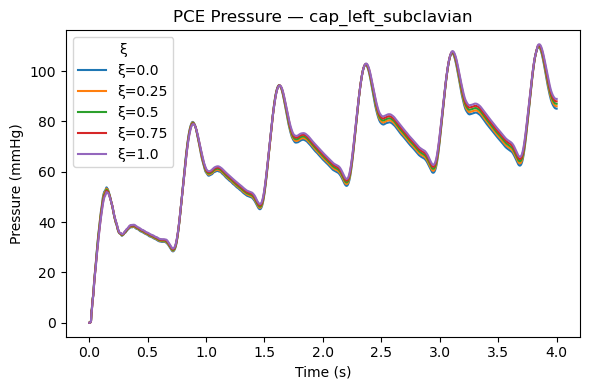

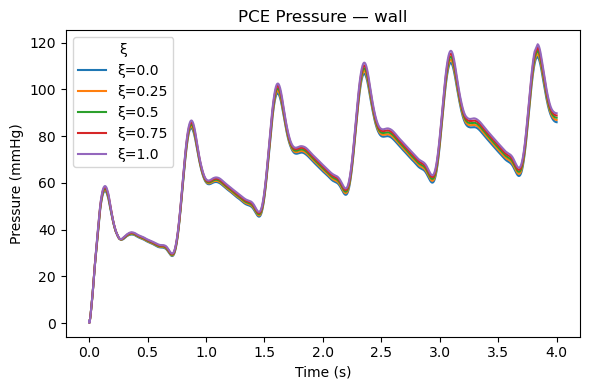

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# helper: drop rows where any of the given cols exceeds Q3 + k·IQR
def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + k * iqr
        mask &= df[c] <= upper
    return df[mask]

# ──────────────────────────────────────────────────────────────────────────────
# 1) Reader functions
def read_pressure_file(filepath):
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                cols = line.strip().split()
                break
    df = pd.read_csv(
        filepath, sep=r'\s+', comment='#',
        header=None, names=cols, skiprows=header_idx+1
    )
    return df.drop(columns=['step'])

def read_velocity_file(filepath):
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                cols = line.strip().split()
                break
    df = pd.read_csv(
        filepath, sep=r'\s+', comment='#',
        header=None, names=cols, skiprows=header_idx+1
    )
    df = df.drop(columns=['step'])
    face_cols = [c for c in df.columns if c != 'time']
    df[face_cols] = df[face_cols].abs()
    return df

# ──────────────────────────────────────────────────────────────────────────────
# 2) Paths
cwd = os.getcwd()
base = os.path.abspath(os.path.join(cwd, os.pardir, os.pardir))
paths = {
    'Inflate': {
        'pressure': os.path.join(base, "svFSI", "svFSI_Inflate",
                                 "aorta_cmm", "48-procs",
                                 "B_CM_Pressure_average.txt"),
        'flux':     os.path.join(base, "svFSI", "svFSI_Inflate",
                                 "aorta_cmm", "48-procs",
                                 "B_CM_Velocity_flux.txt"),
    },
    'Coarctation': {
        'pressure': os.path.join(cwd, "B_CM_Pressure_average.txt"),
        'flux':     os.path.join(cwd, "B_CM_Velocity_flux.txt"),
    }
}

# 3) Sanity‐check
for case, files in paths.items():
    for qty, p in files.items():
        print(f"{case} {qty} → exists? {os.path.exists(p)}")

# ──────────────────────────────────────────────────────────────────────────────
# 4) Read **all** data—no time trimming
dfs_pressure = {}
dfs_flux     = {}
for case, files in paths.items():
    dfp = read_pressure_file(files['pressure'])
    dfv = read_velocity_file(files['flux'])
    dfs_pressure[case] = dfp.reset_index(drop=True)
    dfs_flux    [case] = dfv.reset_index(drop=True)

# 5) Identify face columns
faces_p = [c for c in dfs_pressure['Inflate'].columns if c != 'time']
faces_f = [c for c in dfs_flux    ['Inflate'].columns if c != 'time']

# 6) Remove outliers from both pressure and flux
for case in dfs_pressure:
    before = len(dfs_pressure[case])
    dfs_pressure[case] = remove_outliers_iqr(dfs_pressure[case], faces_p, k=1.5)
    after = len(dfs_pressure[case])
    print(f"{case} pressure: dropped {before-after} / {before} rows")

for case in dfs_flux:
    before = len(dfs_flux[case])
    dfs_flux[case] = remove_outliers_iqr(dfs_flux[case], faces_f, k=1.5)
    after = len(dfs_flux[case])
    print(f"{case} flux: dropped {before-after} / {before} rows")

# ──────────────────────────────────────────────────────────────────────────────
# 7) Build time grid from cleaned Coarctation pressure times
t_grid = dfs_pressure['Coarctation']['time'].values

# 8) Prepare PCE Vandermonde for ξ = [1, 0]
xi = np.array([1.0, 0.0])
V  = np.vstack([np.ones_like(xi), xi]).T   # 2×2

# 9) Compute linear PCE coefficients for pressure
pce_pressure = {}
for face in faces_p:
    # interpolate **Inflate** at Coarctation times
    y_inf = np.interp(t_grid,
                      dfs_pressure['Inflate']['time'],
                      dfs_pressure['Inflate'][face])
    y_coa = np.interp(t_grid,
                      dfs_pressure['Coarctation']['time'],
                      dfs_pressure['Coarctation'][face])
    Q = np.vstack([y_inf, y_coa])          # 2×len(t_grid)
    A = np.linalg.solve(V, Q)              # 2×len(t_grid)
    pce_pressure[face] = (t_grid, A[0], A[1])

# 10) Compute linear PCE coefficients for velocity flux
pce_flux = {}
for face in faces_f:
    y_inf = np.interp(t_grid,
                      dfs_flux['Inflate']['time'],
                      dfs_flux['Inflate'][face])
    y_coa = np.interp(t_grid,
                      dfs_flux['Coarctation']['time'],
                      dfs_flux['Coarctation'][face])
    Q = np.vstack([y_inf, y_coa])
    A = np.linalg.solve(V, Q)
    pce_flux[face] = (t_grid, A[0], A[1])

# ──────────────────────────────────────────────────────────────────────────────
# 11) Plot PCE for pressure
xi_vals = [0.0, 0.25, 0.5, 0.75, 1.0]
for face, (t, a0, a1) in pce_pressure.items():
    plt.figure(figsize=(6,4))
    for xi in xi_vals:
        plt.plot(t, (a0 + a1*xi)/1333.22, label=f'ξ={xi}')
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (mmHg)')
    plt.title(f'PCE Pressure — {face}')
    plt.legend(title='ξ', loc='best')
    plt.tight_layout()
    plt.show()


Inflate pressure → exists? True
Inflate flux → exists? True
Coarctation pressure → exists? True
Coarctation flux → exists? True
Inflate pressure: dropped 208 / 7400 rows
Coarctation pressure: dropped 1 / 4001 rows
Inflate flux: dropped 1649 / 7400 rows
Coarctation flux: dropped 769 / 4001 rows


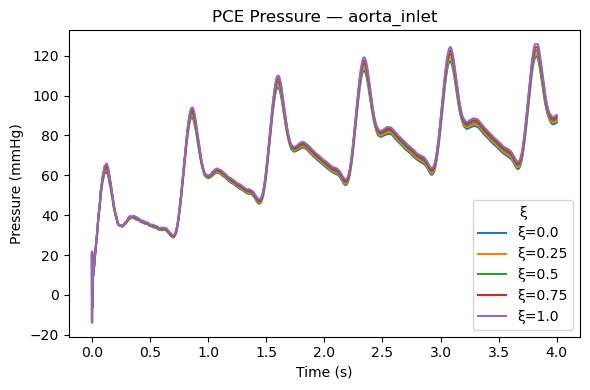

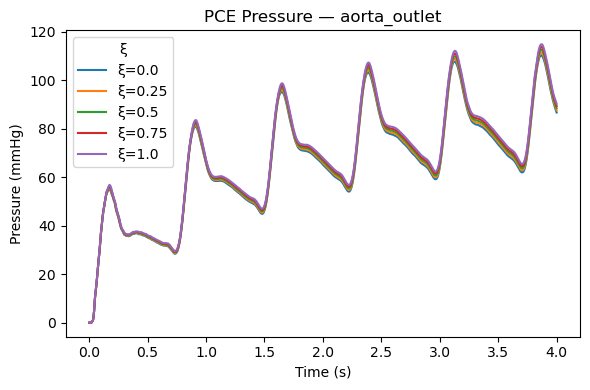

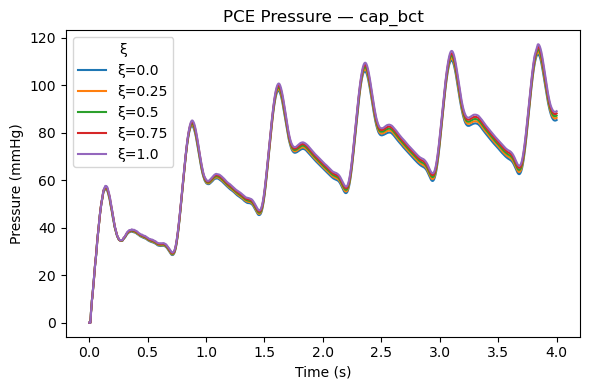

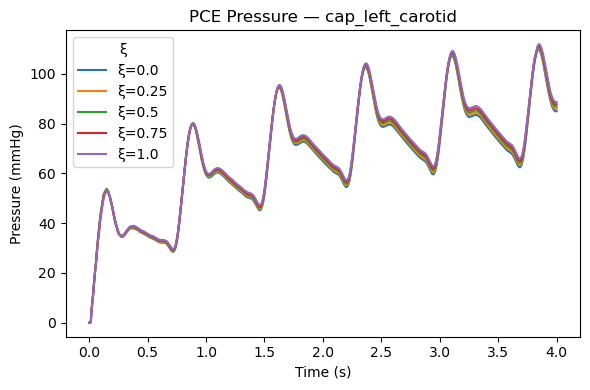

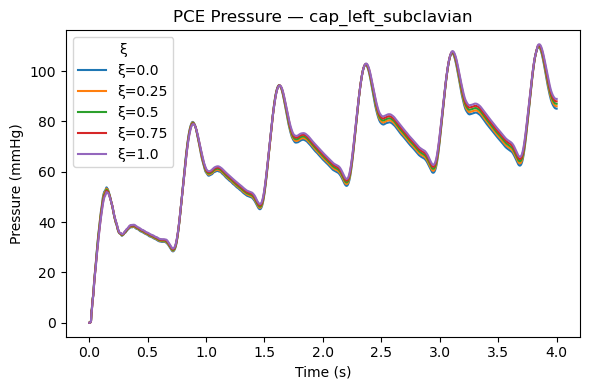

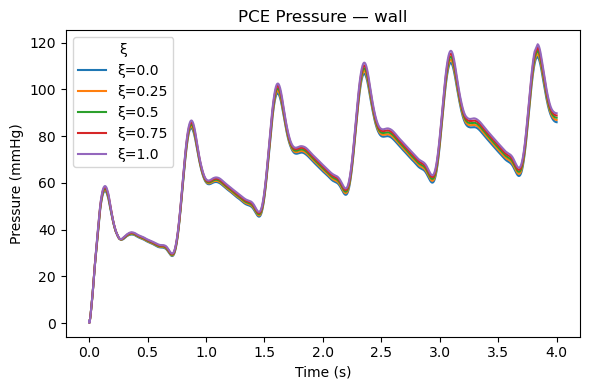

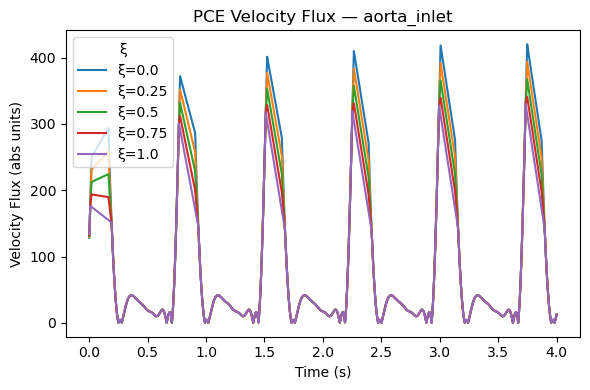

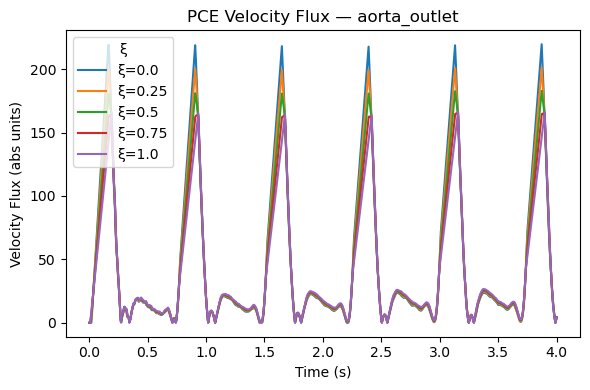

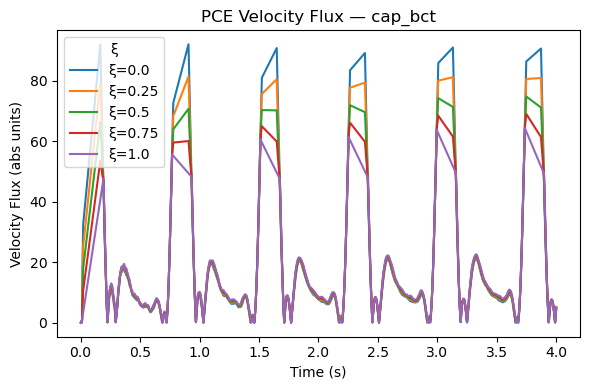

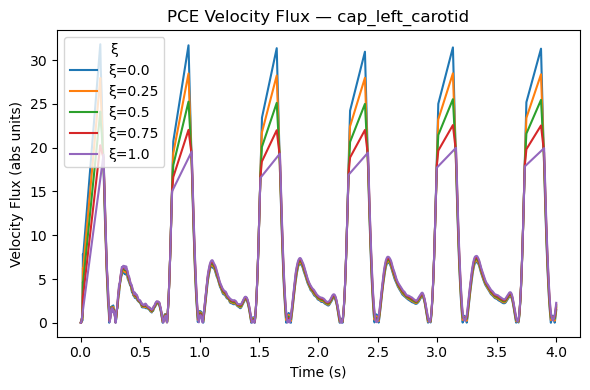

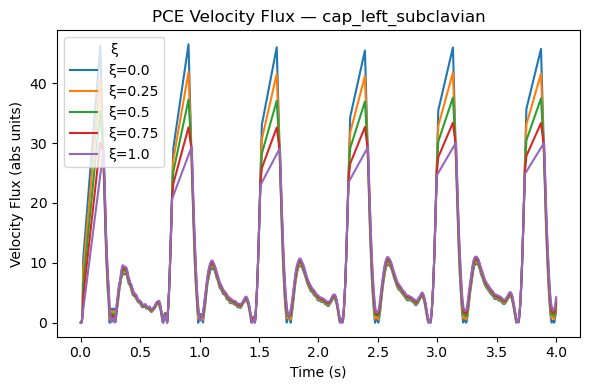

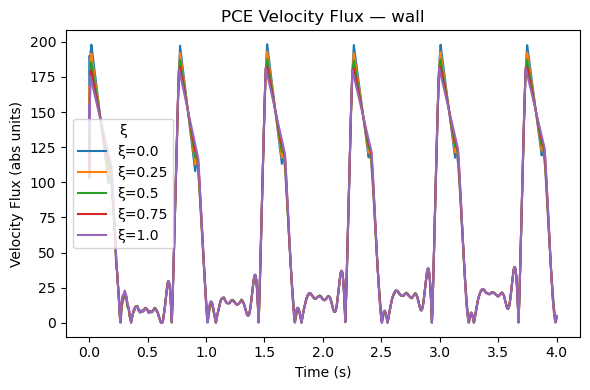

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# helper: drop rows where any of the given cols exceeds Q3 + k·IQR
def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + k * iqr
        mask &= df[c] <= upper
    return df[mask]

# ──────────────────────────────────────────────────────────────────────────────
# 1) Reader functions
def read_pressure_file(filepath):
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                cols = line.strip().split()
                break
    df = pd.read_csv(
        filepath, sep=r'\s+', comment='#',
        header=None, names=cols, skiprows=header_idx+1
    )
    return df.drop(columns=['step'])

def read_velocity_file(filepath):
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            if line.lstrip().startswith("step"):
                header_idx = idx
                cols = line.strip().split()
                break
    df = pd.read_csv(
        filepath, sep=r'\s+', comment='#',
        header=None, names=cols, skiprows=header_idx+1
    )
    df = df.drop(columns=['step'])
    face_cols = [c for c in df.columns if c != 'time']
    df[face_cols] = df[face_cols].abs()
    return df

# ──────────────────────────────────────────────────────────────────────────────
# 2) Paths setup
cwd = os.getcwd()
base = os.path.abspath(os.path.join(cwd, os.pardir, os.pardir))
paths = {
    'Inflate': {
        'pressure': os.path.join(base, "svFSI", "svFSI_Inflate",
                                 "aorta_cmm", "48-procs",
                                 "B_CM_Pressure_average.txt"),
        'flux':     os.path.join(base, "svFSI", "svFSI_Inflate",
                                 "aorta_cmm", "48-procs",
                                 "B_CM_Velocity_flux.txt"),
    },
    'Coarctation': {
        'pressure': os.path.join(cwd, "B_CM_Pressure_average.txt"),
        'flux':     os.path.join(cwd, "B_CM_Velocity_flux.txt"),
    }
}

# 3) Sanity‐check existence
for case, files in paths.items():
    for qty, p in files.items():
        print(f"{case} {qty} → exists? {os.path.exists(p)}")

# ──────────────────────────────────────────────────────────────────────────────
# 4) Read all data (no time trimming)
dfs_pressure = {}
dfs_flux     = {}
for case, files in paths.items():
    dfs_pressure[case] = read_pressure_file(files['pressure']).reset_index(drop=True)
    dfs_flux    [case] = read_velocity_file(files['flux']).reset_index(drop=True)

# 5) Identify face columns
faces_p = [c for c in dfs_pressure['Inflate'].columns if c != 'time']
faces_f = [c for c in dfs_flux    ['Inflate'].columns if c != 'time']

# ──────────────────────────────────────────────────────────────────────────────
# 6) Remove outliers from pressure and flux
for case in dfs_pressure:
    before = len(dfs_pressure[case])
    dfs_pressure[case] = remove_outliers_iqr(dfs_pressure[case], faces_p, k=1.5)
    after = len(dfs_pressure[case])
    print(f"{case} pressure: dropped {before-after} / {before} rows")

for case in dfs_flux:
    before = len(dfs_flux[case])
    dfs_flux[case] = remove_outliers_iqr(dfs_flux[case], faces_f, k=1.5)
    after = len(dfs_flux[case])
    print(f"{case} flux: dropped {before-after} / {before} rows")

# ──────────────────────────────────────────────────────────────────────────────
# 7) Build PCE time‐grid from cleaned Coarctation pressure times
t_grid = dfs_pressure['Coarctation']['time'].values

# 8) Vandermonde for ξ = [1, 0]
xi = np.array([1.0, 0.0])
V  = np.vstack([np.ones_like(xi), xi]).T   # shape (2,2)

# ──────────────────────────────────────────────────────────────────────────────
# 9) Compute linear PCE coefficients for pressure
pce_pressure = {}
for face in faces_p:
    y_inf = np.interp(
        t_grid,
        dfs_pressure['Inflate']['time'],
        dfs_pressure['Inflate'][face]
    )
    y_coa = np.interp(
        t_grid,
        dfs_pressure['Coarctation']['time'],
        dfs_pressure['Coarctation'][face]
    )
    Q = np.vstack([y_inf, y_coa])  # shape (2, len(t_grid))
    A = np.linalg.solve(V, Q)      # shape (2, len(t_grid))
    pce_pressure[face] = (t_grid, A[0], A[1])

# 10) Compute linear PCE coefficients for velocity flux
pce_flux = {}
for face in faces_f:
    y_inf = np.interp(
        t_grid,
        dfs_flux['Inflate']['time'],
        dfs_flux['Inflate'][face]
    )
    y_coa = np.interp(
        t_grid,
        dfs_flux['Coarctation']['time'],
        dfs_flux['Coarctation'][face]
    )
    Q = np.vstack([y_inf, y_coa])
    A = np.linalg.solve(V, Q)
    pce_flux[face] = (t_grid, A[0], A[1])

import os
import matplotlib.pyplot as plt

# make sure output folders exist
outdir_pce_pres = "figures_pce_pressure"
outdir_pce_flux = "figures_pce_flux"
os.makedirs(outdir_pce_pres, exist_ok=True)
os.makedirs(outdir_pce_flux, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# 11) Plot & save PCE for pressure
xi_vals = [0.0, 0.25, 0.5, 0.75, 1.0]
for face, (t, a0, a1) in pce_pressure.items():
    plt.figure(figsize=(6,4))
    for xi in xi_vals:
        plt.plot(t, (a0 + a1*xi)/1333.22, label=f'ξ={xi}')
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (mmHg)')
    plt.title(f'PCE Pressure — {face}')
    plt.legend(title='ξ', loc='best')
    plt.tight_layout()

    # save this figure
    safe_face = face.replace('/', '_').replace(' ', '_')
    plt.savefig(os.path.join(outdir_pce_pres, f"{safe_face}_pce_pressure.png"), dpi=300)
    plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 12) Plot & save PCE for velocity flux
for face, (t, b0, b1) in pce_flux.items():
    plt.figure(figsize=(6,4))
    for xi in xi_vals:
        plt.plot(t, b0 + b1*xi, label=f'ξ={xi}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity Flux (abs units)')
    plt.title(f'PCE Velocity Flux — {face}')
    plt.legend(title='ξ', loc='best')
    plt.tight_layout()

    # save this figure
    safe_face = face.replace('/', '_').replace(' ', '_')
    plt.savefig(os.path.join(outdir_pce_flux, f"{safe_face}_pce_flux.png"), dpi=300)
    plt.show()
